<p style="color:orange; font-size:16px; font-weight:700;">
Name: Ali Abid &  Roll: 380054
</p>


In [156]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [157]:
df = pd.read_csv("Dataset/TSLA.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [161]:
df.columns


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Year'], dtype='object')

In [158]:
df.shape

(2416, 7)

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


## Section A – Exploratory Data Analysis

### 1. Show the trend of Closing Price over the years. (5 marks)

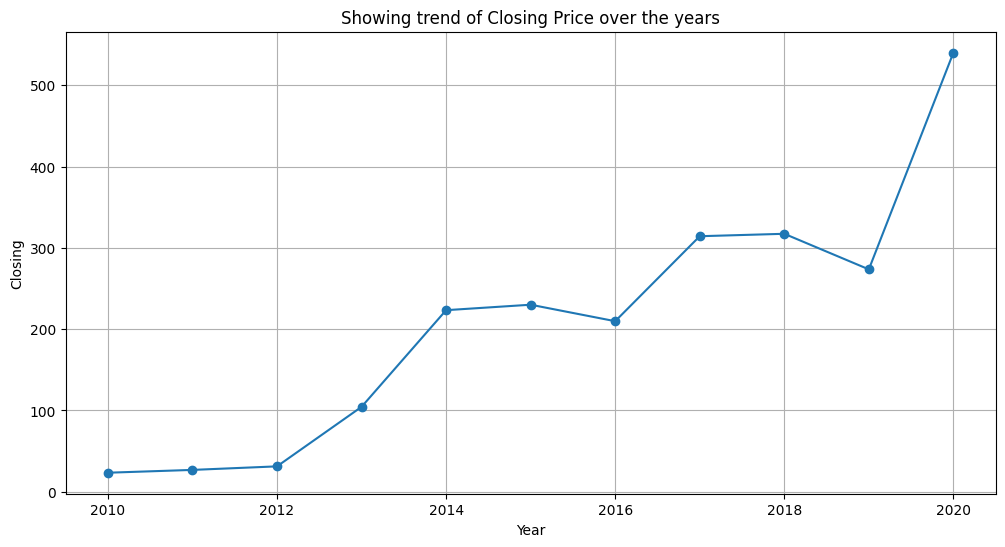

In [160]:
df["Date"] = pd.to_datetime(df["Date"]) # convert to date formatd

df["Year"] = df["Date"].dt.year # gettin Year

# Group by Year and take averaage Close
yearly_data = df.groupby("Year")["Close"].mean().reset_index()
# yearly_data.Year
# yearly_data.Close

plt.figure(figsize=(12,6))
plt.plot(yearly_data.Year, yearly_data.Close, marker="o", )
plt.ylabel("Closing")
plt.xlabel("Year")
plt.title("Showing trend of Closing Price over the years")
plt.grid()
plt.show()

### 2. Find and visualize the correlation between Open, High, Low, and Close. (5 marks)


In [163]:
# Selecting req columns
corr = df[["Open", "High", "Low", "Close"]].corr()
print(corr)

           Open      High       Low     Close
Open   1.000000  0.999425  0.999575  0.998886
High   0.999425  1.000000  0.999389  0.999640
Low    0.999575  0.999389  1.000000  0.999447
Close  0.998886  0.999640  0.999447  1.000000


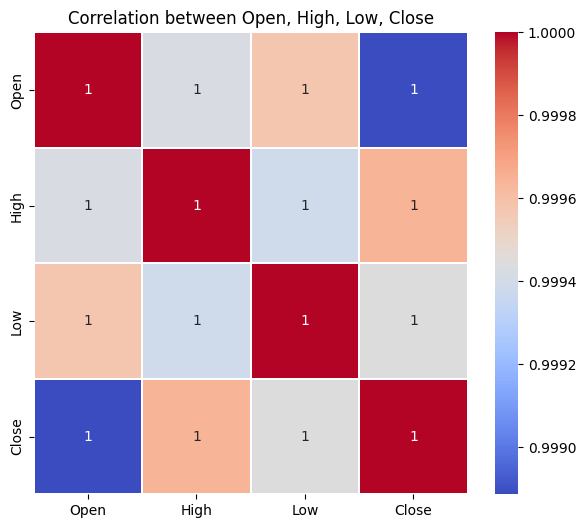

In [169]:
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm" ,linewidths=0.2)
plt.title("Correlation between Open, High, Low, Close")
plt.show()


### 3. Identify the highest and lowest trading volume days and discuss what it might mean for investors. (5 marks)

In [176]:
# Highest volume day
max_vol = df.loc[df["Volume"].idxmax()]

# Lowest volume day
min_vol = df.loc[df["Volume"].idxmin()]
# min_vol = df["Volume"].min() # 118500

print("Highest Volume Day:\n", max_vol)
print("\nLowest Volume Day:\n", min_vol)


Highest Volume Day:
 Date         2020-02-03 00:00:00
Open                  673.690002
High                  786.140015
Low                    673.52002
Close                      780.0
Adj Close                  780.0
Volume                  47065000
Year                        2020
Name: 2415, dtype: object

Lowest Volume Day:
 Date         2010-10-25 00:00:00
Open                   20.940001
High                       20.98
Low                        20.73
Close                      20.85
Adj Close                  20.85
Volume                    118500
Year                        2010
Name: 82, dtype: object


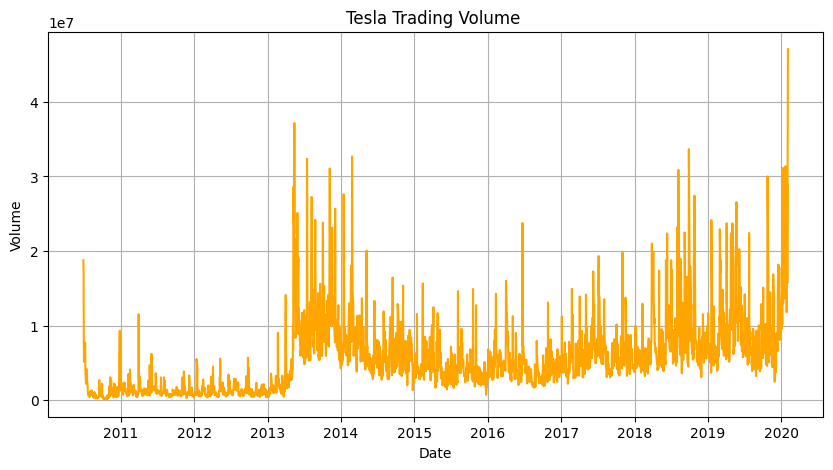

In [178]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Volume"], color="orange")
plt.title("Tesla Trading Volume ")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

### 4. Plot the distribution of Closing Prices

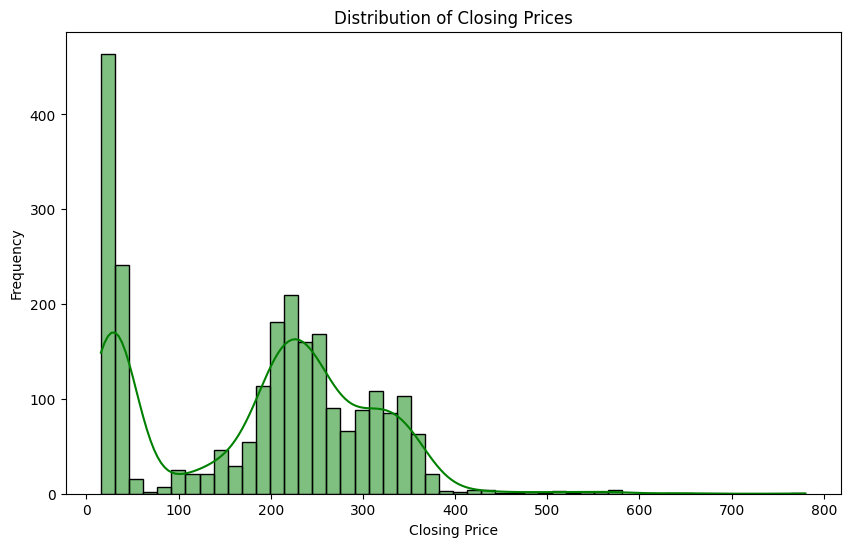

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df["Close"], bins=50, kde=True, color="green")
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()


## 5.Report any missing values or anomalies and suggest how to handle them. (10 marks)

In [213]:
df.isnull().sum() # checking missing values

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Year         0
dtype: int64

In [214]:
# Find anomalies
invalid_prices = df[(df["Open"] <= 0) | (df["High"] <= 0) | (df["Low"] <= 0) | (df["Close"] <= 0)]
high_low_issue = df[df["High"] < df["Low"]]
invalid_volume = df[df["Volume"] < 0]

print("Invalid Prices:\n", invalid_prices)
print("High < Low Issues:\n", high_low_issue)
print("Invalid Volume:\n", invalid_volume)


Invalid Prices:
 Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume, Year]
Index: []
High < Low Issues:
 Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume, Year]
Index: []
Invalid Volume:
 Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume, Year]
Index: []


In [218]:
# Prices should be > 0
invalid_prices = df[(df["Open"] <= 0) | (df["High"] <= 0) | 
                    (df["Low"] <= 0) | (df["Close"] <= 0)]

# High should not be decrease than Low
high_low_issue = df[df["High"] < df["Low"]]

# Volume should not be negative
invalid_volume = df[df["Volume"] < 0]

print("Invalid Prices:", invalid_prices)
print("High < Low Issues:", high_low_issue)
print("Invalid Volumes:", invalid_volume)


Invalid Prices: Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume, Year]
Index: []
High < Low Issues: Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume, Year]
Index: []
Invalid Volumes: Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume, Year]
Index: []


In [ ]:
Q1 = df["Close"].quantile(0.25)
Q3 = df["Close"].quantile(0.75)
IQR = Q3 - Q1 

outliers = df[(df["Close"] < (Q1 - 1.5 * IQR)) | (df["Close"] > (Q3 + 1.5 * IQR))]
print(outliers)


           Date        Open        High        Low       Close   Adj Close  \
2413 2020-01-30  632.419983  650.880005  618.00000  640.809998  640.809998   
2414 2020-01-31  640.000000  653.000000  632.52002  650.570007  650.570007   
2415 2020-02-03  673.690002  786.140015  673.52002  780.000000  780.000000   

        Volume  Year  
2413  29005700  2020  
2414  15719300  2020  
2415  47065000  2020  


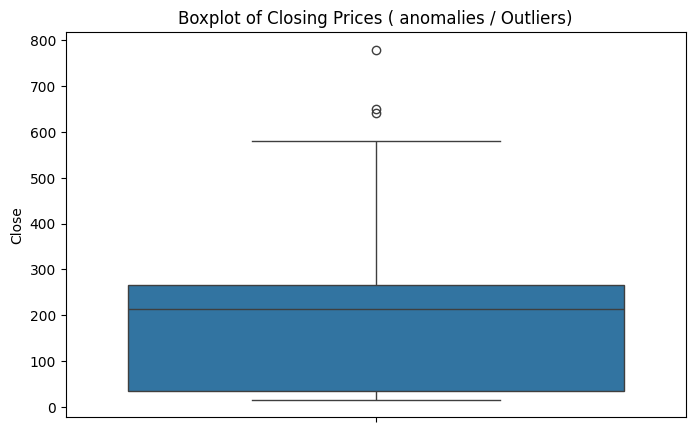

In [229]:
plt.figure(figsize=(8,5))
sns.boxplot(df["Close"])
plt.title("Boxplot of Closing Prices ( anomalies / Outliers)") # outliers
plt.show()


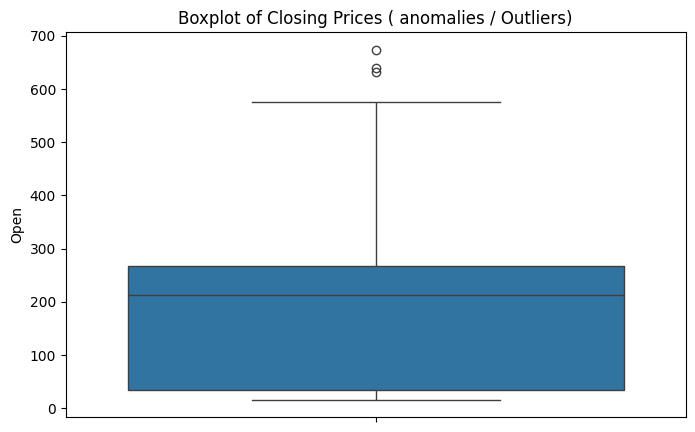

In [227]:
plt.figure(figsize=(8,5))
sns.boxplot(df["Open"])
plt.title("Boxplot of Closing Prices ( anomalies / Outliers)") # outliers
plt.show()


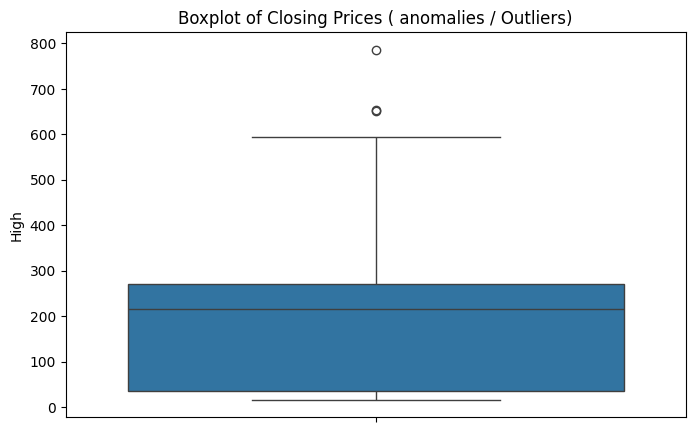

In [228]:
plt.figure(figsize=(8,5))
sns.boxplot(df["High"])
plt.title("Boxplot of Closing Prices ( anomalies / Outliers)") # outliers
plt.show()


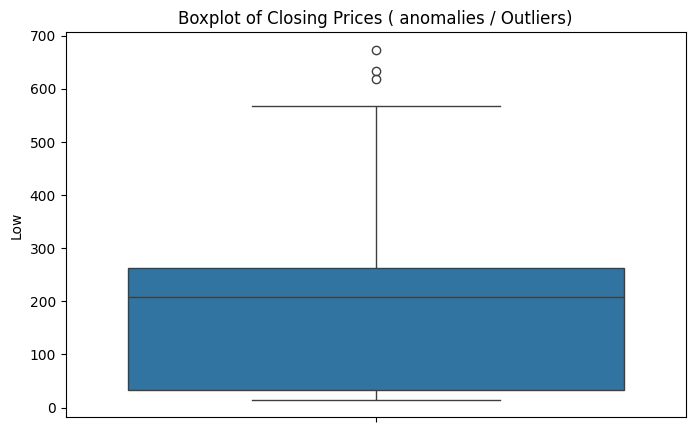

In [230]:
plt.figure(figsize=(8,5))
sns.boxplot(df["Low"])
plt.title("Boxplot of Closing Prices ( anomalies / Outliers)") # outliers
plt.show()


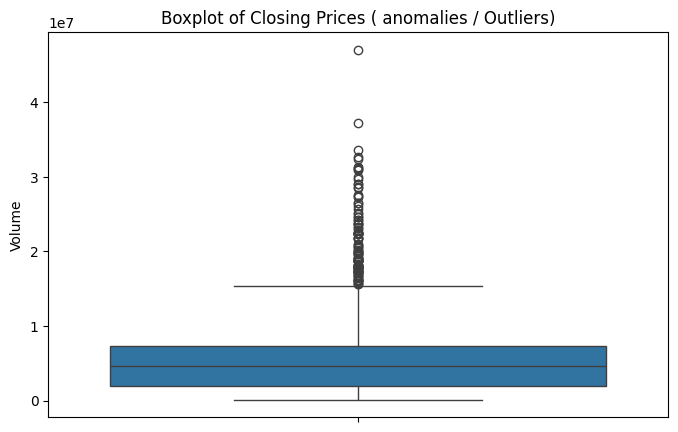

In [231]:
plt.figure(figsize=(8,5))
sns.boxplot(df["Volume"])
plt.title("Boxplot of Closing Prices ( anomalies / Outliers)") # outliers
plt.show()